In [7]:
import ipywidgets as widgets
import numpy as np
import pandas as pd
from IPython.display import display
import edhec_risk_kit as erk
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def show_gbm(n_scenarios, mu, sigma):
    '''
    draw the results of a stock price , with brownian motion
    '''
    s_0=100
    prices= erk.gbm1(n_scenarios=n_scenarios, mu=mu , sigma=sigma , s_0=s_0)
    ax = prices.plot(legend = False , figsize=(12,6), alpha=0.5,color='red')
    ax.axhline(y=s_0,ls=':')
    ax.set_ylim(top=400)
    #draw a dot at the origin
    ax.plot(0,s_0,marker='o', alpha=0.2)

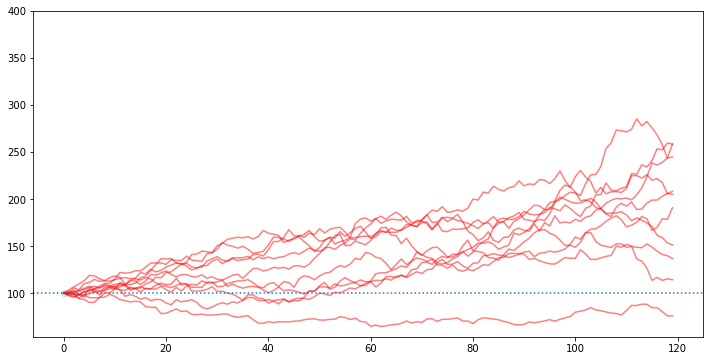

In [3]:
show_gbm(10,0.07,0.1)

In [4]:
gbm_controls = widgets.interactive(show_gbm,
                                   n_scenarios=(1,20,1),
                                   mu = (0,0.2,0.01),
                                   sigma = (0,0.3,0.01)
                                  )

In [5]:
display(gbm_controls)

interactive(children=(IntSlider(value=10, description='n_scenarios', max=20, min=1), FloatSlider(value=0.1, de…

In [17]:
def show_cppi(n_scenarios=50,mu=0.07,sigma=0.15,m=3,floor=0.,riskfree_rate=0.03,y_max=100):
    """
    plot the monte carlo results of cppi
    """
    start = 100
    sim_rets = erk.gbm(n_scenarios=n_scenarios, mu=mu, sigma=sigma,prices=False ,steps_per_year=12)
    risky_r = pd.DataFrame(sim_rets)
    #run the backtest
    btr = erk.run_cppi(risky_r=pd.DataFrame(risky_r), riskfree_rate=riskfree_rate, m=m, start=start, floor=floor)
    wealth = btr['wealth']
    y_max = wealth.values.max()*y_max/100
    terminal_wealth = wealth.iloc[-1]
    
    tw_mean = terminal_wealth.mean()
    tw_median = terminal_wealth.median()
    failure_mask = np.less(terminal_wealth,start*floor)
    n_failures = failure_mask.sum()
    p_fail = n_failures/n_scenarios
    e_shortfall = np.dot(terminal_wealth-start*floor,failure_mask)/n_failures if n_failures > 0 else 0.0
    
    #plot
    fig,(wealth_ax,hist_ax)=plt.subplots(nrows=1, ncols=2, sharey=True, gridspec_kw={'width_ratios':[3,2]},figsize=(24,9))
    plt.subplots_adjust(wspace=0.0)
    
    ax = wealth.plot(ax=wealth_ax, legend=False, alpha=0.3, figsize=(12,6))
    ax.axhline(y=start,ls=":",color='black')
    ax.axhline(y=start*floor,ls='--',color='red')
    ax.set_ylim(top=y_max)
    
    terminal_wealth.plot.hist(ax=hist_ax, bins=50, ec='w', orientation='horizontal')
    hist_ax.axhline(y=start,ls=":")
    hist_ax.axhline(y=tw_mean,ls=':',color='blue')
    hist_ax.axhline(y=tw_median,ls=":",color='orange')
    hist_ax.annotate(f"Mean:${int(tw_mean)}",xy=(.7,.9),xycoords='axes fraction',fontsize=24)
    hist_ax.annotate(f"Median:${int(tw_median)}",xy=(.7,.85),xycoords='axes fraction',fontsize=24)
    if (floor>0.01):
        hist_ax.axhline(y=start*floor,ls='--',color='green')
        hist_ax.annotate(f"Violations:{n_failures}",xy=(.7,.7),xycoords='axes fraction',fontsize=24)
        hist_ax.annotate(f"shortfall:{e_shortfall}",xy=(.7,.6),xycoords='axes fraction',fontsize=24)
        
        
    
    
cppi_controls=widgets.interactive(show_cppi,
                                  n_scenarios = widgets.IntSlider(min=1, max=1000, step=5, value=50),
                                  mu=(0., +.2, .01),
                                  sigma=(0,.5,.05),
                                  floor=(0,2,.1),
                                  m=(1,5,.5),
                                  riskfree_rate=(0, .05, .01),
                                  y_max=widgets.IntSlider(min=0,max=100,step=1,value=100, description='Zoom Y Axis')
                                 )
display(cppi_controls)

interactive(children=(IntSlider(value=50, description='n_scenarios', max=1000, min=1, step=5), FloatSlider(val…